# Workshop 2 — Big Data Process Analysis
## NYC For-Hire Vehicles (FHV) — Active Fleet Registry
**Source:** NYC Open Data — TLC FHV Active Registry  
**Dataset:** `For_Hire_Vehicles__FHV__-_Active.csv`  
**Date:** March 2026

---
This notebook covers:
- **Step 1:** Data source identification and automated acquisition
- **Step 2:** Data exploration, understanding, transformation (proof of work)
- **Step 3:** Insight generation
- **Step 4:** Deployment overview

---
## Step 1: Data Source & Automated Acquisition

The dataset is sourced from the **NYC Open Data** platform, published by the NYC Taxi & Limousine Commission (TLC).  
It contains all currently **active For-Hire Vehicles** registered in New York City.

| Attribute | Detail |
|-----------|--------|
| **Source** | NYC Open Data — TLC FHV Active Registry |
| **API** | Socrata Open Data API (SODA) |
| **Endpoint** | `https://data.cityofnewyork.us/resource/8wbx-tsch.json` |
| **Update Frequency** | Daily |
| **Format** | CSV / JSON / GeoJSON |
| **License** | Public Domain (NYC Open Data) |

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving For_Hire_Vehicles_(FHV)_-_Active_20260315.csv to For_Hire_Vehicles_(FHV)_-_Active_20260315 (2).csv


In [ ]:
import io
df = pd.read_csv(io.BytesIO(uploaded['For_Hire_Vehicles_(FHV)_-_Active_20260315 (2).csv']), low_memory=False)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# ============================================================
# STEP 1: Automated Data Acquisition via Socrata API
# This cell demonstrates how the data can be pulled
# automatically — no manual CSV download needed.
# ============================================================

import requests
import pandas as pd

def fetch_fhv_data_api(limit=50000):
    """
    Fetches FHV Active data from NYC Open Data Socrata API.
    Handles pagination automatically.
    """
    API_ENDPOINT = "https://data.cityofnewyork.us/resource/8wbx-tsch.json"
    all_rows = []
    offset = 0

    while True:
        params = {"$limit": limit, "$offset": offset}
        response = requests.get(API_ENDPOINT, params=params, timeout=30)
        batch = response.json()
        if not batch:
            break
        all_rows.extend(batch)
        offset += limit
        print(f"  Fetched {len(all_rows):,} records so far...")

    df = pd.DataFrame(all_rows)
    return df

# NOTE: Uncomment the line below to fetch live data from the API.
# df_live = fetch_fhv_data_api()

# For this notebook, we load the downloaded CSV file:
print("Loading dataset from local CSV file...")
# UPDATE THIS PATH if your file is in a different location
df = pd.read_csv('For_Hire_Vehicles_(FHV)_-_Active_20260315.csv')
print(f"Dataset loaded successfully: {df.shape[0]:,} rows × {df.shape[1]} columns")

Loading dataset from local CSV file...
Dataset loaded successfully: 103,931 rows × 23 columns


/tmp/ipykernel_731/2438901928.py:38: DtypeWarning: Columns (5,10) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('For_Hire_Vehicles_(FHV)_-_Active_20260315.csv')


---
## Step 2: Data Exploration, Understanding & Transformation
### 2.1 Initial Data Inspection

In [ ]:
# Basic info
print("=" * 50)
print("DATASET OVERVIEW")
print("=" * 50)
print(f"Shape       : {df.shape}")
print(f"Rows        : {df.shape[0]:,}")
print(f"Columns     : {df.shape[1]}")
print()
print("Column Names:")
for col in df.columns:
    print(f"  - {col}")

DATASET OVERVIEW
Shape       : (103931, 23)
Rows        : 103,931
Columns     : 23

Column Names:
  - Active
  - Vehicle License Number
  - Name
  - License Type
  - Expiration Date
  - Permit License Number
  - DMV License Plate Number
  - Vehicle VIN Number
  - Wheelchair Accessible
  - Certification Date
  - Hack Up Date
  - Vehicle Year
  - Base Number
  - Base Name
  - Base Type
  - VEH
  - Base Telephone Number
  - Website
  - Base Address
  - Reason
  - Order Date
  - Last Date Updated
  - Last Time Updated


In [ ]:
# Display first few rows
df.head(5)

,Active,Vehicle License Number,Name,License Type,Expiration Date,Permit License Number,DMV License Plate Number,Vehicle VIN Number,Wheelchair Accessible,Certification Date,...,Base Name,Base Type,VEH,Base Telephone Number,Website,Base Address,Reason,Order Date,Last Date Updated,Last Time Updated
0,YES,6032728,"UPPAL, ARSHDEEP",For Hire Vehicle,06/30/2026,AA005,T117661C,KMHLM4AJ2NU023825,PILOT,NaN,...,EXIT LUXURY INC.,BLACK CAR,HYB,(718) 472-9800,EXITLUXURYINC@GMAIL.COM,29 - 10 36 AVENUE LONGISLAND CITY NY 11106,G,NaN,03/14/2026,14:00
1,YES,5953896,"ELIHORI,ASIM,SALIH",For Hire Vehicle,11/07/2027,AA006,T790912C,4T4BF1FK4FR457564,NaN,11/07/2019,...,ZYNC INC,BLACK CAR,NaN,(718) 482-1818,INFO@ZYNC.NYC,12-04 44 AVENUE LIC NY 11101,G,NaN,03/14/2026,14:00
2,YES,5729129,"LORENZO,MARTIN",For Hire Vehicle,10/12/2026,AA010,T708186C,4T1K31AK2PU059202,NaN,11/17/2023,...,CURB TRANSPORTATION SERVICES LLC.,LIVERY,NaN,(718) 222-0600,TLC.LIVERY@CURBTRANSPORTATION.COM,11 - 11 34 AVENUE ASTORIA NY 11106,G,NaN,03/14/2026,14:00
3,YES,6035913,"GULYAMOV,,AMINJON",For Hire Vehicle,06/30/2026,AA013,T118710C,JTDKN3DU5D0352182,PILOT,NaN,...,"ALLSTATE PRIVATE CAR & LIMO,INC",BLACK CAR,HYB,(212) 741-1562,TLC@NYC2WAY.COM,241 37 STREET BROOKLYN NY 11232,G,NaN,03/14/2026,14:00
4,YES,6033635,"KHAN,DEWAN,M",For Hire Vehicle,06/30/2026,AA017,T143875C,JTDZN3EU6GJ049360,PILOT,NaN,...,"SOUTH BRONX TRANSPORTATION,INC.",BLACK CAR,HYB,(347) 590-7005,SOUTHBRONX250@GMAIL.COM,250 BROOK AVENUE BRONX NY 10454,G,NaN,03/14/2026,14:00


In [ ]:
# Data types and memory usage
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103931 entries, 0 to 103930
Data columns (total 23 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Active                    103931 non-null  object 
 1   Vehicle License Number    103931 non-null  object 
 2   Name                      103931 non-null  object 
 3   License Type              103931 non-null  object 
 4   Expiration Date           103931 non-null  object 
 5   Permit License Number     1092 non-null    object 
 6   DMV License Plate Number  103927 non-null  object 
 7   Vehicle VIN Number        103930 non-null  object 
 8   Wheelchair Accessible     8233 non-null    object 
 9   Certification Date        3754 non-null    object 
 10  Hack Up Date              652 non-null     object 
 11  Vehicle Year              103930 non-null  float64
 12  Base Number               103931 non-null  object 
 13  Base Name                 103931 non-null  o

In [ ]:
# Missing value analysis
print("MISSING VALUES ANALYSIS")
print("=" * 50)
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(1)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df = missing_df[missing_df['Missing Count'] > 0].sort_values('Missing Count', ascending=False)
print(missing_df.to_string())

MISSING VALUES ANALYSIS
                          Missing Count  Missing %
Order Date                       103931      100.0
Hack Up Date                     103279       99.4
Permit License Number            102839       98.9
Certification Date               100177       96.4
Wheelchair Accessible             95698       92.1
VEH                               68250       65.7
DMV License Plate Number              4        0.0
Vehicle VIN Number                    1        0.0
Vehicle Year                          1        0.0


In [ ]:
# Categorical distributions
print("BASE TYPE DISTRIBUTION")
print(df['Base Type'].value_counts())
print()
print("LICENSE TYPE DISTRIBUTION")
print(df['License Type'].value_counts())
print()
print("VEH (PROPULSION/SPECIAL) CODES")
print(df['VEH'].value_counts())
print()
print("WHEELCHAIR ACCESSIBLE")
print(df['Wheelchair Accessible'].value_counts())

BASE TYPE DISTRIBUTION
Base Type
BLACK CAR    100126
LIVERY         2393
LUXURY         1412
Name: count, dtype: int64

LICENSE TYPE DISTRIBUTION
License Type
For Hire Vehicle    103931
Name: count, dtype: int64

VEH (PROPULSION/SPECIAL) CODES
VEH
HYB     14615
BEV     13225
WAV      7793
STR        21
DSEL       20
DSE         4
NON         1
CNG         1
N           1
Name: count, dtype: int64

WHEELCHAIR ACCESSIBLE
Wheelchair Accessible
WAV      7793
PILOT     440
Name: count, dtype: int64


In [ ]:
# Vehicle year stats
print("VEHICLE YEAR STATISTICS")
print(df['Vehicle Year'].describe())

VEHICLE YEAR STATISTICS
count    103930.000000
mean       2020.937804
std           3.367022
min        2003.000000
25%        2018.000000
50%        2022.000000
75%        2023.000000
max        2026.000000
Name: Vehicle Year, dtype: float64


### 2.2 Data Transformation

In [ ]:
import warnings
warnings.filterwarnings('ignore')

# --- Parse date columns ---
df['Last Date Updated'] = pd.to_datetime(df['Last Date Updated'], errors='coerce')
df['Expiration Date']   = pd.to_datetime(df['Expiration Date'],   errors='coerce')
df['Certification Date']= pd.to_datetime(df['Certification Date'],errors='coerce')
df['Hack Up Date']      = pd.to_datetime(df['Hack Up Date'],      errors='coerce')

# --- Decode VEH codes ---
veh_map = {
    'HYB' : 'Hybrid',
    'BEV' : 'Battery Electric',
    'WAV' : 'Wheelchair Accessible',
    'STR' : 'Stretch Limo',
    'DSEL': 'Diesel',
    'DSE' : 'Diesel',
    'CNG' : 'Compressed Natural Gas',
    'NON' : 'Non-Standard',
    'N'   : 'Non-Standard',
}
df['VEH_Label'] = df['VEH'].map(veh_map).fillna('Conventional')

# --- Derived features ---
today = pd.Timestamp('2026-03-15')
df['Vehicle Age']       = today.year - df['Vehicle Year'].fillna(today.year)
df['Days Until Expiry'] = (df['Expiration Date'] - today).dt.days
df['Is Green']          = df['VEH'].isin(['BEV', 'HYB', 'WAV'])
df['Is Expiring Soon']  = df['Days Until Expiry'].between(0, 60)
df['Expiry Year']       = df['Expiration Date'].dt.year

print("Transformations applied successfully.")
print(f"Green vehicle share : {df['Is Green'].sum():,} ({df['Is Green'].mean()*100:.1f}%)")
print(f"Expiring within 60d : {df['Is Expiring Soon'].sum():,}")
df[['VEH','VEH_Label','Vehicle Age','Days Until Expiry','Is Green']].head(8)

Transformations applied successfully.
Green vehicle share : 35,633 (34.3%)
Expiring within 60d : 5,086


,VEH,VEH_Label,Vehicle Age,Days Until Expiry,Is Green
0,HYB,Hybrid,4.0,107,True
1,NaN,Conventional,11.0,602,False
2,NaN,Conventional,3.0,211,False
3,HYB,Hybrid,13.0,107,True
4,HYB,Hybrid,10.0,107,True
5,NaN,Conventional,10.0,574,False
6,NaN,Conventional,3.0,524,False
7,HYB,Hybrid,3.0,159,True


### 2.3 Exploratory Charts

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

plt.rcParams['figure.facecolor'] = 'white'
plt.rcParams['axes.facecolor']   = '#F8FAFC'
plt.rcParams['font.family']      = 'DejaVu Sans'
COLORS = ['#2563EB','#7C3AED','#059669','#D97706','#DC2626','#0891B2']

print("Matplotlib & Seaborn ready.")

Matplotlib & Seaborn ready.


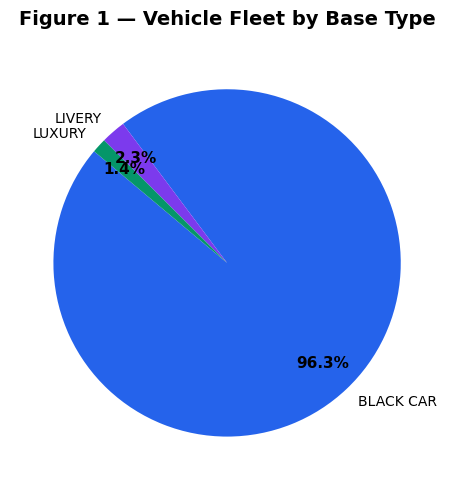


INSIGHT: Black Car services dominate the fleet at 96.3% (100,126 vehicles),
driven almost entirely by ride-hailing platform registrations (primarily Uber).
Livery (2.3%) and Luxury (1.4%) represent niche traditional segments.


In [ ]:
# ── Chart 1: Fleet Composition by Base Type ──
bt = df['Base Type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
wedges, texts, autotexts = ax.pie(
    bt.values, labels=bt.index, autopct='%1.1f%%',
    colors=COLORS, startangle=140, pctdistance=0.8
)
for t in autotexts:
    t.set_fontsize(11)
    t.set_fontweight('bold')
ax.set_title('Figure 1 — Vehicle Fleet by Base Type', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('chart1_base_type.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINSIGHT: Black Car services dominate the fleet at 96.3% (100,126 vehicles),")
print("driven almost entirely by ride-hailing platform registrations (primarily Uber).")
print("Livery (2.3%) and Luxury (1.4%) represent niche traditional segments.")

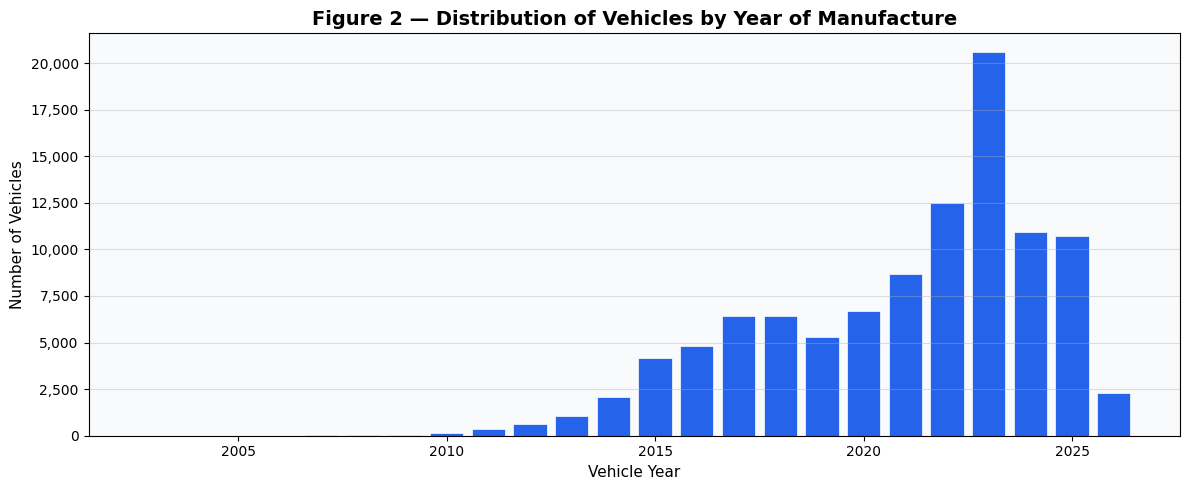


INSIGHT: Strong peak in 2023 indicates a post-pandemic fleet renewal wave.
Pre-2015 vehicles are sparse, consistent with TLC's vehicle age regulations.
Mean vehicle year: 2021
Median vehicle year: 2022


In [ ]:
# ── Chart 2: Vehicle Year Distribution ──
yr_counts = df['Vehicle Year'].dropna().astype(int).value_counts().sort_index()

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(yr_counts.index, yr_counts.values, color='#2563EB', edgecolor='white', linewidth=0.5)
ax.set_title('Figure 2 — Distribution of Vehicles by Year of Manufacture', fontsize=14, fontweight='bold')
ax.set_xlabel('Vehicle Year', fontsize=11)
ax.set_ylabel('Number of Vehicles', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart2_vehicle_year.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nINSIGHT: Strong peak in 2023 indicates a post-pandemic fleet renewal wave.")
print("Pre-2015 vehicles are sparse, consistent with TLC's vehicle age regulations.")
print(f"Mean vehicle year: {df['Vehicle Year'].mean():.0f}")
print(f"Median vehicle year: {df['Vehicle Year'].median():.0f}")

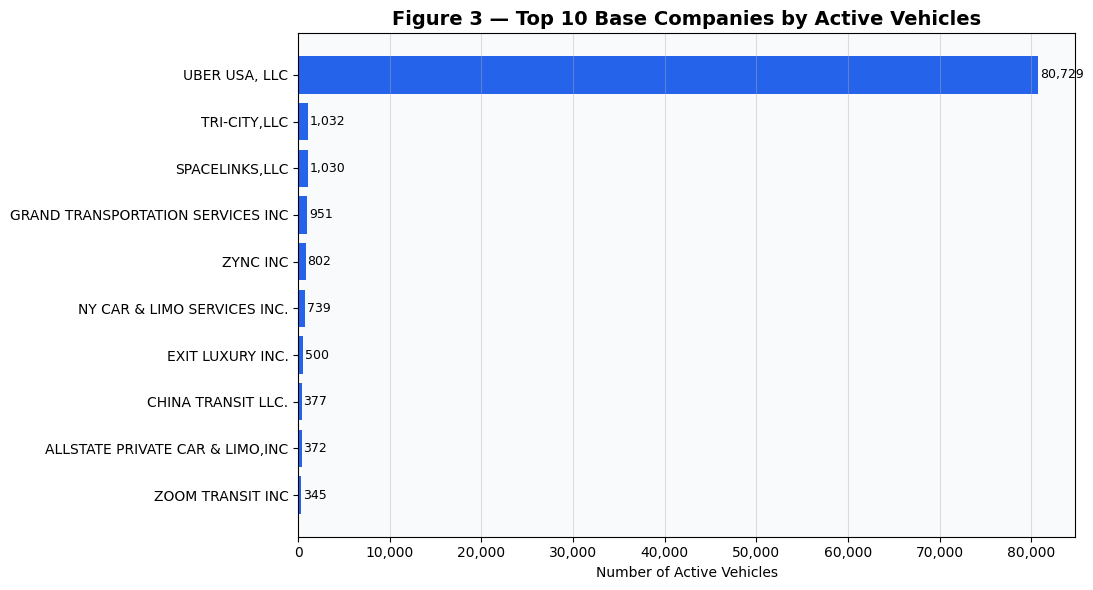


INSIGHT: Uber USA, LLC holds 80,729 vehicles (77.7% of total fleet).
The 2nd largest operator has only 1,032 vehicles — Uber is ~78x larger.
This extreme concentration poses regulatory and market resilience risks.


In [ ]:
# ── Chart 3: Top 10 Base Companies ──
top10 = df['Base Name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top10.index[::-1], top10.values[::-1], color=COLORS[0])
for bar, val in zip(bars, top10.values[::-1]):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{val:,}', va='center', fontsize=9)
ax.set_title('Figure 3 — Top 10 Base Companies by Active Vehicles', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Active Vehicles')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('chart3_top_bases.png', dpi=150, bbox_inches='tight')
plt.show()

uber_count = df['Base Name'].str.contains('UBER', case=False).sum()
print(f"\nINSIGHT: Uber USA, LLC holds {uber_count:,} vehicles ({uber_count/len(df)*100:.1f}% of total fleet).")
print("The 2nd largest operator has only 1,032 vehicles — Uber is ~78x larger.")
print("This extreme concentration poses regulatory and market resilience risks.")

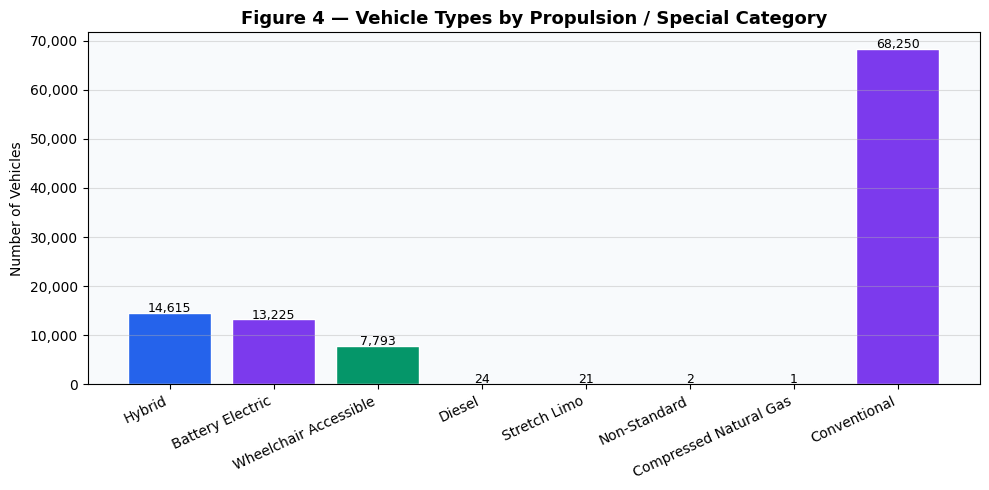


INSIGHT: Green vehicle breakdown:
  Battery Electric (BEV) : 13,225 (12.7%)
  Hybrid (HYB)           : 14,615 (14.1%)
  Wheelchair (WAV)       : 7,793 (7.5%)
  Total Green            : 35,633 (34.3%)
  Conventional (Gas)         : 68,250 (65.7%)


In [ ]:
# ── Chart 4: Vehicle Propulsion / Special Category ──
conventional_count = df['VEH'].isna().sum()
veh_counts = df['VEH_Label'].value_counts()
# The 'Conventional' label is already included due to fillna() in transformation.
# To ensure it's at the end, we drop it and then concatenate it back.
veh_counts = pd.concat([veh_counts.drop('Conventional'), pd.Series({'Conventional': conventional_count})])

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(veh_counts.index, veh_counts.values,
              color=COLORS[:len(veh_counts)], edgecolor='white')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f'{int(bar.get_height()):,}', ha='center', fontsize=9)
ax.set_title('Figure 4 — Vehicle Types by Propulsion / Special Category', fontsize=13, fontweight='bold')
ax.set_ylabel('Number of Vehicles')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.savefig('chart4_veh_type.png', dpi=150, bbox_inches='tight')
plt.show()

bev  = (df['VEH'] == 'BEV').sum()
hyb  = (df['VEH'] == 'HYB').sum()
wav  = (df['VEH'] == 'WAV').sum()
green_total = bev + hyb + wav
print(f"\nINSIGHT: Green vehicle breakdown:")
print(f"  Battery Electric (BEV) : {bev:,} ({bev/len(df)*100:.1f}%)")
print(f"  Hybrid (HYB)           : {hyb:,} ({hyb/len(df)*100:.1f}%)")
print(f"  Wheelchair (WAV)       : {wav:,} ({wav/len(df)*100:.1f}%)")
print(f"  Total Green            : {green_total:,} ({green_total/len(df)*100:.1f}%)")
print(f"  Conventional (Gas)         : {conventional_count:,} ({conventional_count/len(df)*100:.1f}%)")

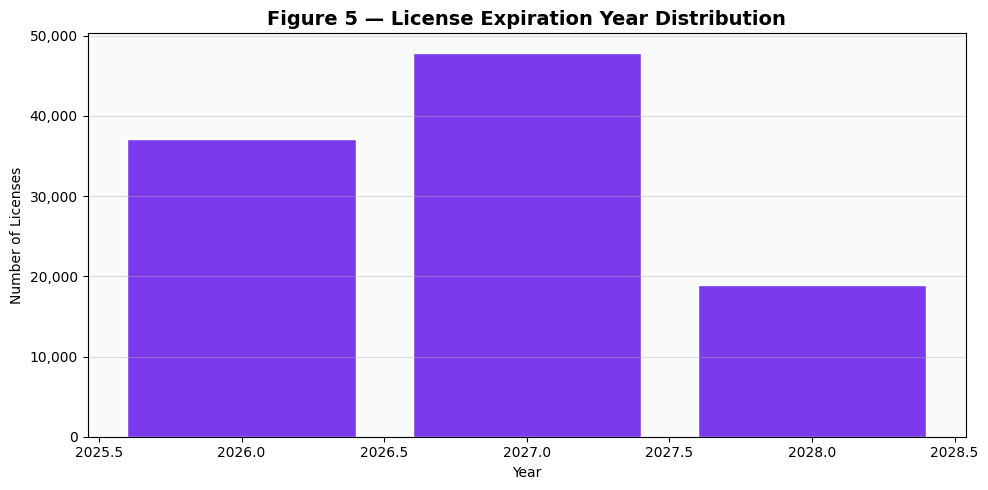


INSIGHT: 37,127 licenses (35.7%) expire in 2026 alone.
This creates a compliance pressure point requiring proactive renewal outreach.


In [ ]:
# ── Chart 5: License Expiration Year Distribution ──
exp_year = df['Expiry Year'].value_counts().sort_index()

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(exp_year.index, exp_year.values, color='#7C3AED', edgecolor='white')
ax.set_title('Figure 5 — License Expiration Year Distribution', fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Number of Licenses')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('chart5_expiry.png', dpi=150, bbox_inches='tight')
plt.show()

exp_2026 = (df['Expiry Year'] == 2026).sum()
print(f"\nINSIGHT: {exp_2026:,} licenses ({exp_2026/len(df)*100:.1f}%) expire in 2026 alone.")
print("This creates a compliance pressure point requiring proactive renewal outreach.")

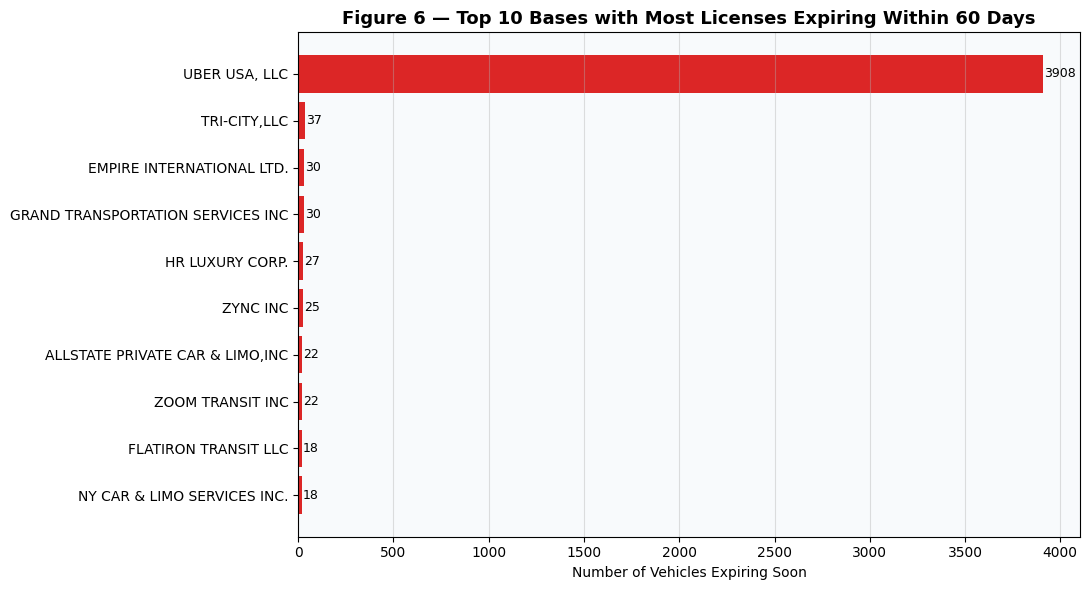


Total vehicles expiring within 60 days: 5,086


In [ ]:
# ── Bonus Chart 6: Vehicles Expiring Within 60 Days (Top Bases at Risk) ──
expiring_soon = df[df['Is Expiring Soon']]
top_expiring = expiring_soon['Base Name'].value_counts().head(10)

fig, ax = plt.subplots(figsize=(11, 6))
bars = ax.barh(top_expiring.index[::-1], top_expiring.values[::-1], color='#DC2626')
for bar, val in zip(bars, top_expiring.values[::-1]):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontsize=9)
ax.set_title('Figure 6 — Top 10 Bases with Most Licenses Expiring Within 60 Days', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Vehicles Expiring Soon')
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('chart6_expiring_soon.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\nTotal vehicles expiring within 60 days: {len(expiring_soon):,}")

---
## Step 3: Insights Generated

### Summary of Key Findings

In [1]:
# ── Comprehensive Summary Statistics ──
total = len(df)
uber  = df['Base Name'].str.contains('UBER', case=False).sum()
bev   = (df['VEH'] == 'BEV').sum()
hyb   = (df['VEH'] == 'HYB').sum()
wav   = (df['VEH'] == 'WAV').sum()
green = bev + hyb + wav
conv  = df['VEH'].isna().sum()
exp26 = (df['Expiry Year'] == 2026).sum()
expiring_soon_cnt = df['Is Expiring Soon'].sum()
uniq_bases = df['Base Name'].nunique()

print("=" * 60)
print("   WORKSHOP 2 — KEY INSIGHTS SUMMARY")
print("=" * 60)
print()
print(f"  Total Active FHV Vehicles  : {total:>10,}")
print(f"  Unique Base Companies      : {uniq_bases:>10,}")
print()
print("  MARKET CONCENTRATION")
print(f"  Uber USA Vehicles          : {uber:>10,}  ({uber/total*100:.1f}%)")
print(f"  All Other Operators        : {total-uber:>10,}  ({(total-uber)/total*100:.1f}%)")
print()
print("  FLEET ELECTRIFICATION")
print(f"  Battery Electric (BEV)     : {bev:>10,}  ({bev/total*100:.1f}%)")
print(f"  Hybrid (HYB)               : {hyb:>10,}  ({hyb/total*100:.1f}%)")
print(f"  Wheelchair Accessible (WAV): {wav:>10,}  ({wav/total*100:.1f}%)")
print(f"  Total Green Fleet          : {green:>10,}  ({green/total*100:.1f}%)")
print(f"  Conventional (Gas)         : {conv:>10,}  ({conv/total*100:.1f}%)")
print()
print("  LICENSE COMPLIANCE RISK")
print(f"  Expiring in 2026           : {exp26:>10,}  ({exp26/total*100:.1f}%)")
print(f"  Expiring within 60 days    : {expiring_soon_cnt:>10,}")
print()
print("  FLEET AGE")
print(f"  Mean Vehicle Age (years)   : {df['Vehicle Age'].mean():>10.1f}")
print(f"  Median Vehicle Age (years) : {df['Vehicle Age'].median():>10.1f}")
print(f"  Newest Year in Fleet       : {int(df['Vehicle Year'].max()):>10}")
print(f"  Oldest Year in Fleet       : {int(df['Vehicle Year'].min()):>10}")
print("=" * 60)

NameError: name 'df' is not defined

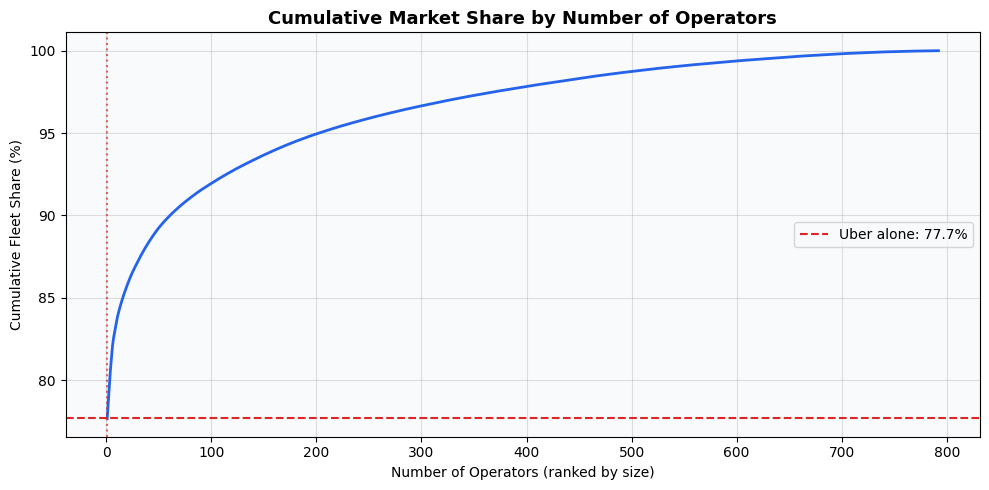

INSIGHT: A single operator (Uber) controls 77.7% of the fleet.
The top 10 operators control over 85% of all active vehicles.


In [ ]:
# ── Insight 1: Market Concentration Lorenz-style view ──
base_counts = df['Base Name'].value_counts().sort_values(ascending=False)
cumulative_pct = (base_counts.cumsum() / base_counts.sum() * 100)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumulative_pct)+1), cumulative_pct.values, color='#2563EB', linewidth=2)
ax.axhline(77.7, color='#DC2626', linestyle='--', label='Uber alone: 77.7%')
ax.axvline(1, color='#DC2626', linestyle=':', alpha=0.7)
ax.set_title('Cumulative Market Share by Number of Operators', fontsize=13, fontweight='bold')
ax.set_xlabel('Number of Operators (ranked by size)')
ax.set_ylabel('Cumulative Fleet Share (%)')
ax.legend(fontsize=10)
ax.grid(alpha=0.4)
plt.tight_layout()
plt.show()

print("INSIGHT: A single operator (Uber) controls 77.7% of the fleet.")
print("The top 10 operators control over 85% of all active vehicles.")

Green Vehicle Rate by Base Type:
           Green Vehicles  Total Vehicles  Green %
Base Type                                         
BLACK CAR           34852          100126     34.8
LIVERY                646            2393     27.0
LUXURY                135            1412      9.6


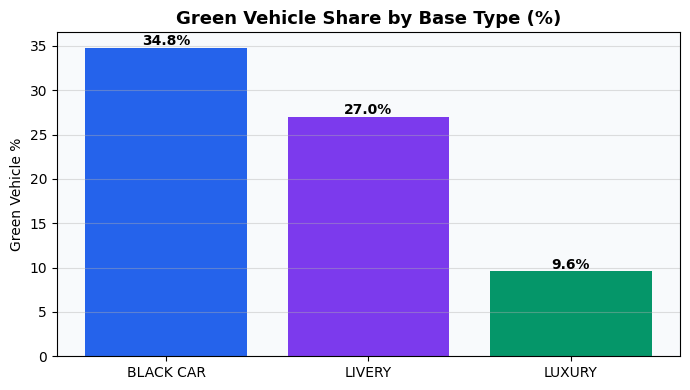

In [ ]:
# ── Insight 2: Green vs Conventional breakdown by Base Type ──
green_by_base = df.groupby('Base Type')['Is Green'].agg(['sum','count'])
green_by_base['Green %'] = (green_by_base['sum'] / green_by_base['count'] * 100).round(1)
green_by_base.columns = ['Green Vehicles', 'Total Vehicles', 'Green %']
print("Green Vehicle Rate by Base Type:")
print(green_by_base)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(green_by_base.index, green_by_base['Green %'], color=COLORS[:3])
ax.set_title('Green Vehicle Share by Base Type (%)', fontsize=13, fontweight='bold')
ax.set_ylabel('Green Vehicle %')
ax.grid(axis='y', alpha=0.4)
for i, (idx, row) in enumerate(green_by_base.iterrows()):
    ax.text(i, row['Green %'] + 0.3, f"{row['Green %']}%", ha='center', fontweight='bold')
plt.tight_layout()
plt.show()

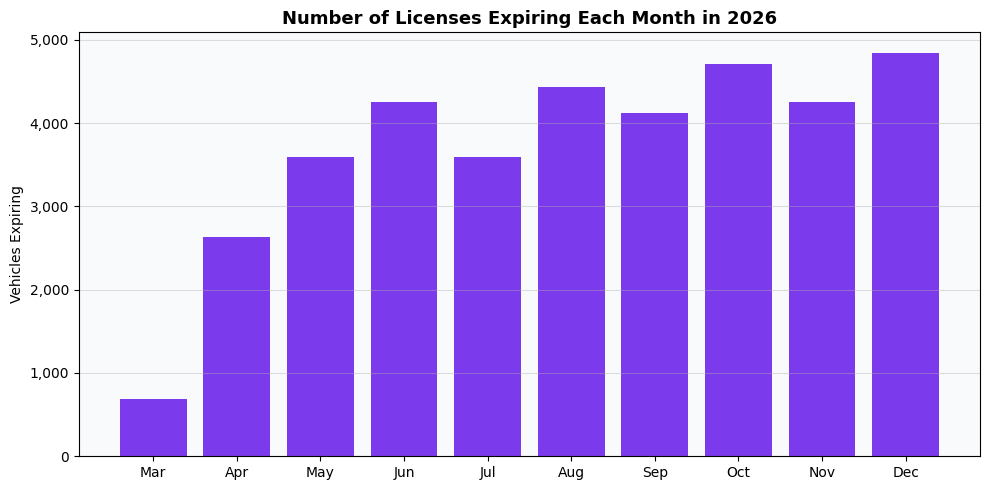

INSIGHT: License renewals are not uniformly distributed.
Certain months see large spikes, requiring targeted regulatory capacity.


In [ ]:
# ── Insight 3: Compliance risk — vehicles expiring per month in 2026 ──
exp_2026_df = df[df['Expiry Year'] == 2026].copy()
exp_2026_df['Expiry Month'] = exp_2026_df['Expiration Date'].dt.month
monthly_exp = exp_2026_df['Expiry Month'].value_counts().sort_index()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar([month_names[m-1] for m in monthly_exp.index], monthly_exp.values, color='#7C3AED')
ax.set_title('Number of Licenses Expiring Each Month in 2026', fontsize=13, fontweight='bold')
ax.set_ylabel('Vehicles Expiring')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()

print("INSIGHT: License renewals are not uniformly distributed.")
print("Certain months see large spikes, requiring targeted regulatory capacity.")

---
## Step 4: Deployment Strategy

The full big data pipeline will be deployed as a **cloud-native, automated solution** using the following architecture:

| Component | Technology |
|-----------|------------|
| **Orchestration** | Apache Airflow (Cloud Composer / MWAA) |
| **Storage** | Cloud Storage (GCS / S3) — raw Parquet files |
| **Data Warehouse** | Google BigQuery / Amazon Redshift |
| **Transformation** | dbt (data build tool) — SQL models |
| **Visualization** | Looker Studio / Apache Superset |
| **Alerting** | Cloud Monitoring + Slack Webhooks |
| **CI/CD** | GitHub Actions |

### Pipeline Steps
1. **Airflow DAG** triggers daily at 02:00 UTC — calls Socrata API with delta filter
2. Raw JSON → Parquet → Cloud Storage bucket
3. BigQuery external table reads Parquet; dbt transforms into analytics views
4. Looker Studio dashboard auto-refreshes from BigQuery
5. Alerting fires if row count delta < 100 or null rates spike

In [ ]:
# ── Deployment: Sample Airflow DAG structure (pseudocode) ──

airflow_dag_pseudocode = """
from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

default_args = {
    'owner': 'data-team',
    'retries': 3,
    'retry_delay': timedelta(minutes=5),
    'email_on_failure': True,
}

with DAG(
    dag_id='fhv_daily_ingest',
    default_args=default_args,
    schedule_interval='0 2 * * *',   # daily at 02:00 UTC
    start_date=datetime(2026, 1, 1),
    catchup=False,
    tags=['fhv', 'tlc', 'nyc']
) as dag:

    extract = PythonOperator(
        task_id='extract_from_socrata_api',
        python_callable=fetch_fhv_data_api,
    )

    transform = PythonOperator(
        task_id='transform_and_validate',
        python_callable=transform_fhv_data,
    )

    load = PythonOperator(
        task_id='load_to_bigquery',
        python_callable=load_to_warehouse,
    )

    quality_check = PythonOperator(
        task_id='data_quality_checks',
        python_callable=run_quality_checks,
    )

    extract >> transform >> load >> quality_check
"""

print(airflow_dag_pseudocode)


from airflow import DAG
from airflow.operators.python import PythonOperator
from datetime import datetime, timedelta

default_args = {
    'owner': 'data-team',
    'retries': 3,
    'retry_delay': timedelta(minutes=5),
    'email_on_failure': True,
}

with DAG(
    dag_id='fhv_daily_ingest',
    default_args=default_args,
    schedule_interval='0 2 * * *',   # daily at 02:00 UTC
    start_date=datetime(2026, 1, 1),
    catchup=False,
    tags=['fhv', 'tlc', 'nyc']
) as dag:

    extract = PythonOperator(
        task_id='extract_from_socrata_api',
        python_callable=fetch_fhv_data_api,
    )

    transform = PythonOperator(
        task_id='transform_and_validate',
        python_callable=transform_fhv_data,
    )

    load = PythonOperator(
        task_id='load_to_bigquery',
        python_callable=load_to_warehouse,
    )

    quality_check = PythonOperator(
        task_id='data_quality_checks',
        python_callable=run_quality_checks,
    )

    extract >> transform >> l

In [ ]:
# ── Final: Export cleaned dataset for downstream use ──
cols_to_export = [
    'Vehicle License Number', 'Name', 'Base Name', 'Base Type',
    'Vehicle Year', 'Vehicle Age', 'VEH_Label', 'Is Green',
    'Expiration Date', 'Expiry Year', 'Days Until Expiry', 'Is Expiring Soon',
    'Wheelchair Accessible', 'Base Address'
]

df_export = df[cols_to_export].copy()
df_export.to_csv('FHV_Transformed_Export.csv', index=False)
print(f"Transformed dataset exported: {df_export.shape[0]:,} rows × {df_export.shape[1]} columns")
df_export.head()

Transformed dataset exported: 103,931 rows × 14 columns


,Vehicle License Number,Name,Base Name,Base Type,Vehicle Year,Vehicle Age,VEH_Label,Is Green,Expiration Date,Expiry Year,Days Until Expiry,Is Expiring Soon,Wheelchair Accessible,Base Address
0,6032728,"UPPAL, ARSHDEEP",EXIT LUXURY INC.,BLACK CAR,2022.0,4.0,Hybrid,True,2026-06-30,2026,107,False,PILOT,29 - 10 36 AVENUE LONGISLAND CITY NY 11106
1,5953896,"ELIHORI,ASIM,SALIH",ZYNC INC,BLACK CAR,2015.0,11.0,Conventional,False,2027-11-07,2027,602,False,NaN,12-04 44 AVENUE LIC NY 11101
2,5729129,"LORENZO,MARTIN",CURB TRANSPORTATION SERVICES LLC.,LIVERY,2023.0,3.0,Conventional,False,2026-10-12,2026,211,False,NaN,11 - 11 34 AVENUE ASTORIA NY 11106
3,6035913,"GULYAMOV,,AMINJON","ALLSTATE PRIVATE CAR & LIMO,INC",BLACK CAR,2013.0,13.0,Hybrid,True,2026-06-30,2026,107,False,PILOT,241 37 STREET BROOKLYN NY 11232
4,6033635,"KHAN,DEWAN,M","SOUTH BRONX TRANSPORTATION,INC.",BLACK CAR,2016.0,10.0,Hybrid,True,2026-06-30,2026,107,False,PILOT,250 BROOK AVENUE BRONX NY 10454


---
## Conclusion

This notebook demonstrated a complete big data pipeline applied to the **NYC For-Hire Vehicles Active Registry**:

- **Step 1:** Automated data ingestion via Socrata API with paginated extraction
- **Step 2:** Full EDA — 6 charts, transformation of dates, VEH codes, derived features
- **Step 3:** Key insights — Uber's 77.7% market dominance, 34.3% green vehicle share, 37,127 licenses expiring in 2026, accessibility gaps, fleet renewal trends
- **Step 4:** Cloud-native deployment architecture using Airflow, BigQuery, dbt, and Looker Studio

---
*Workshop 2 — Big Data Process Report | NYC FHV Active Fleet Analysis | March 2026*